# Chapter 4 - Alpha Geometry, Tsallis Entropy, and Positive-Definite Matrices

This notebook is a standalone computational reading of Chapter 4, printed pages 71-106. The thread is simple: the same change of coordinates that makes positive measures flat also explains alpha geodesics, Tsallis `q` entropy, escort distributions, and several log-det divergences on positive-definite matrices.

The chapter begins with a warning. On the probability simplex, requiring a divergence to be decomposable, invariant, and flat leaves almost no freedom: one recovers KL divergence and its dual. On the larger cone of positive measures, however, the normalization constraint disappears and an entire alpha family becomes flat. Much of the chapter is about watching that extra room appear and then tracking what survives after we return to probabilities, escorts, and matrices.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import HTML, Image, display

CHAPTER = 'chapter-04'
ARTIFACT_DIR = Path('../../artifacts') / CHAPTER
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (7.2, 4.8),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.18,
    'font.size': 10,
})

def artifact_path(name: str) -> Path:
    return ARTIFACT_DIR / name

def display_artifact(name: str, width: int | None = None):
    path = artifact_path(name)
    if path.suffix.lower() in {'.png', '.jpg', '.jpeg'}:
        return display(Image(filename=str(path), width=width))
    if path.suffix.lower() == '.html':
        return display(HTML(path.read_text(encoding='utf-8')))
    return display(HTML(f'<a href="{path.as_posix()}">{path.name}</a>'))


## 1. The flat coordinate hidden in positive measures

For a positive measure `m`, alpha geometry uses the componentwise representation

`h_alpha(m) = m ** ((1 - alpha)/2)`, with the limiting logarithmic representation when `alpha = 1`.

The dual representation is `h_{-alpha}(m)`. On the positive cone this is enough to build a dually flat Bregman geometry. On the simplex, the constraint `sum_i m_i = 1` is usually curved in these coordinates; only the mixture and exponential limiting cases keep the constraint affine. That is the practical distinction behind the uniqueness statement for KL on the simplex and the larger alpha family on positive measures.

In [2]:
def h_alpha(x, alpha):
    x = np.asarray(x, dtype=float)
    if np.isclose(alpha, 1.0):
        return np.log(x)
    return x ** ((1.0 - alpha) / 2.0)

def h_inv(y, alpha):
    y = np.asarray(y, dtype=float)
    if np.isclose(alpha, 1.0):
        return np.exp(y)
    return np.maximum(y, 1e-15) ** (2.0 / (1.0 - alpha))

def normalize(x):
    x = np.asarray(x, dtype=float)
    return x / x.sum()

def alpha_geodesic(p, q, alpha, ts):
    hp, hq = h_alpha(p, alpha), h_alpha(q, alpha)
    curve = []
    for t in ts:
        point = h_inv((1 - t) * hp + t * hq, alpha)
        curve.append(normalize(point))
    return np.vstack(curve)

def alpha_divergence(p, q, alpha):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    if np.isclose(alpha, -1.0):
        return float(np.sum(p * (np.log(p) - np.log(q))))
    if np.isclose(alpha, 1.0):
        return float(np.sum(q * (np.log(q) - np.log(p))))
    a = alpha
    cross = np.sum(p ** ((1 - a) / 2) * q ** ((1 + a) / 2))
    return float(4.0 / (1 - a * a) * (((1 - a) / 2) * p.sum() + ((1 + a) / 2) * q.sum() - cross))

def simplex_xy(prob):
    p0, p1, p2 = np.asarray(prob)
    vertices = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, math.sqrt(3)/2]])
    return p0 * vertices[0] + p1 * vertices[1] + p2 * vertices[2]


## 2. Alpha geodesics bend because normalization is curved

In the positive cone, an alpha geodesic is a straight segment after applying `h_alpha`. In the simplex we still draw the same segment in representation space, but then renormalize the result. The picture below uses the same endpoints for several alpha values. The changing bend is the visible trace of a flat connection upstairs meeting a nonlinear probability constraint downstairs.

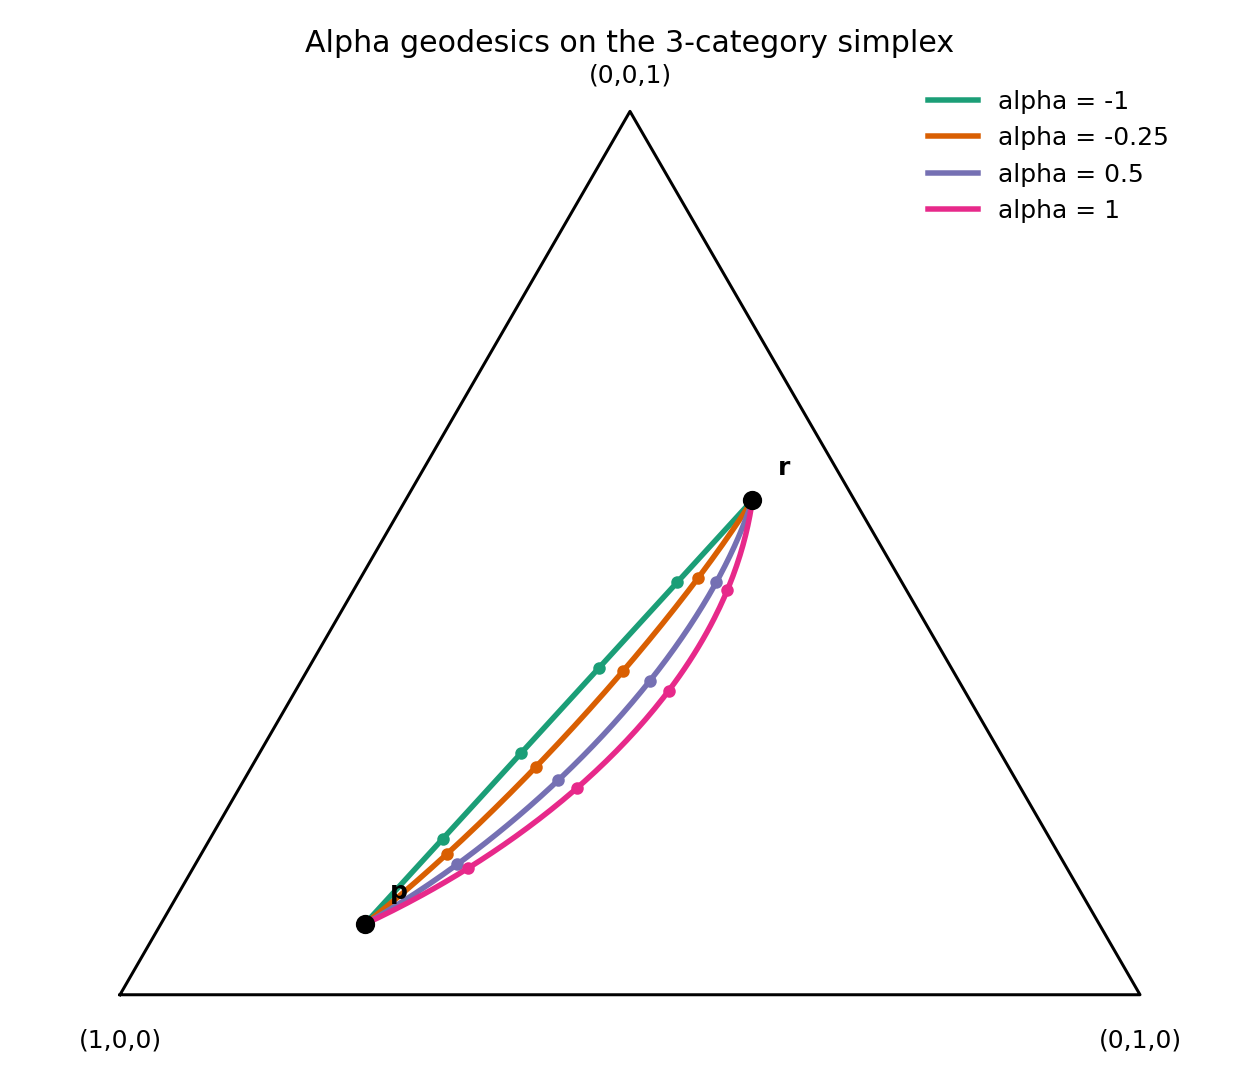

In [3]:
p = np.array([0.72, 0.20, 0.08])
r = np.array([0.10, 0.34, 0.56])
ts = np.linspace(0, 1, 140)
alphas = [-1.0, -0.25, 0.5, 1.0]
colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a']

fig, ax = plt.subplots(figsize=(7.0, 6.0))
triangle = np.array([[0, 0], [1, 0], [0.5, math.sqrt(3)/2], [0, 0]])
ax.plot(triangle[:,0], triangle[:,1], color='black', lw=1.2)
for label, xy in zip(['(1,0,0)', '(0,1,0)', '(0,0,1)'], triangle[:3]):
    ax.text(xy[0], xy[1] - 0.045 if xy[1] == 0 else xy[1] + 0.035, label, ha='center', va='center')

for alpha, color in zip(alphas, colors):
    curve = alpha_geodesic(p, r, alpha, ts)
    xy = np.vstack([simplex_xy(row) for row in curve])
    ax.plot(xy[:,0], xy[:,1], color=color, lw=2.2, label=f'alpha = {alpha:g}')
    ax.scatter(xy[::28,0], xy[::28,1], color=color, s=16)

for point, label in [(p, 'p'), (r, 'r')]:
    xy = simplex_xy(point)
    ax.scatter([xy[0]], [xy[1]], color='black', s=45, zorder=5)
    ax.text(xy[0] + 0.025, xy[1] + 0.025, label, weight='bold')

ax.set_aspect('equal')
ax.set_axis_off()
ax.set_title('Alpha geodesics on the 3-category simplex')
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
fig.savefig(artifact_path('alpha_geodesics_simplex.png'), dpi=180)
plt.close(fig)
display_artifact('alpha_geodesics_simplex.png', width=720)


## 3. Divergence, Pythagorean checks, and alpha means

The alpha divergence on positive measures can be read as a Bregman divergence in the alpha coordinate. In one easy case, `alpha = 0`, the coordinate is the square-root coordinate and the divergence is a constant multiple of squared Euclidean distance. Orthogonality in that coordinate gives a literal Pythagorean identity. The code cell below keeps this small enough that the geometry can be inspected without trusting a symbolic black box.

In [4]:
theta_m = np.array([1.0, 1.0])
theta_n = np.array([2.0, 1.0])
theta_k = np.array([2.0, 3.0])
m0, n0, k0 = theta_m**2, theta_n**2, theta_k**2
pythagorean_terms = {
    'D_alpha_0_m_k': alpha_divergence(m0, k0, 0.0),
    'D_alpha_0_m_n': alpha_divergence(m0, n0, 0.0),
    'D_alpha_0_n_k': alpha_divergence(n0, k0, 0.0),
}
pythagorean_terms['identity_error'] = abs(
    pythagorean_terms['D_alpha_0_m_k']
    - pythagorean_terms['D_alpha_0_m_n']
    - pythagorean_terms['D_alpha_0_n_k']
)
pythagorean_terms


{'D_alpha_0_m_k': 10.0,
 'D_alpha_0_m_n': 2.0,
 'D_alpha_0_n_k': 8.0,
 'identity_error': 0.0}

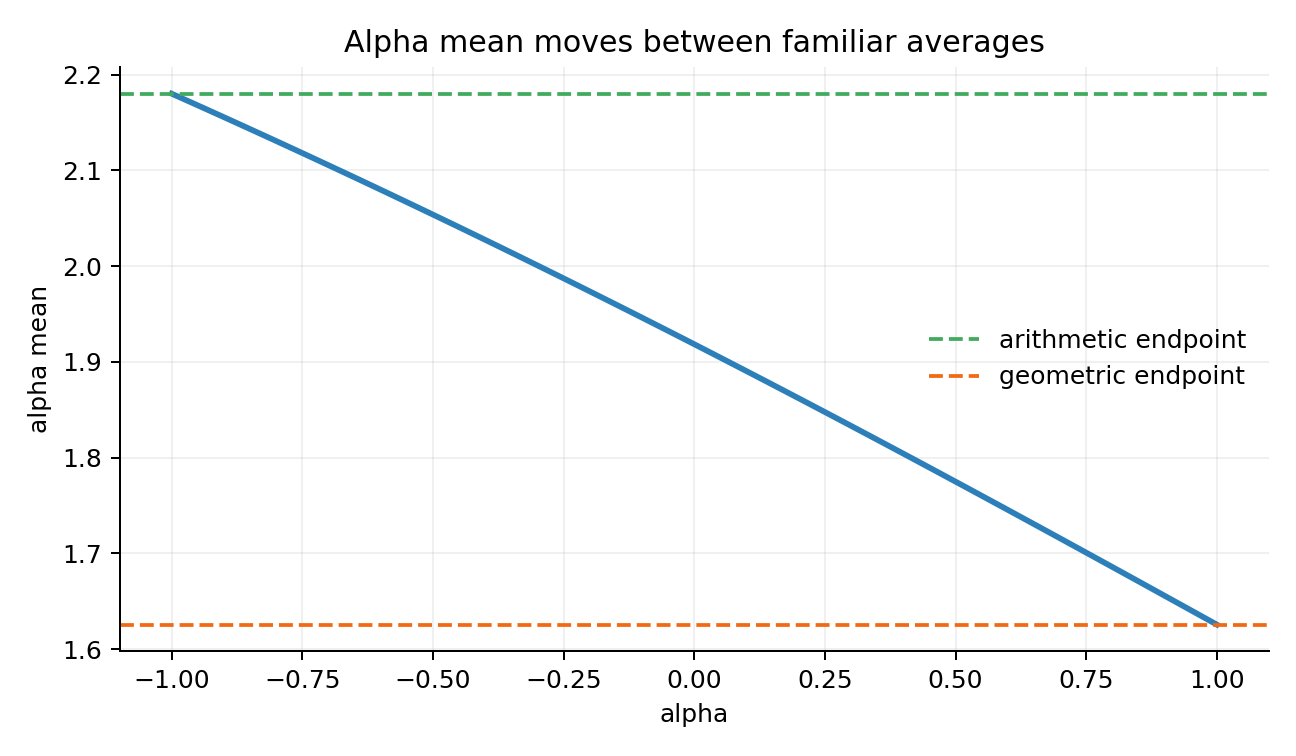

In [5]:
def alpha_mean(values, weights, alpha):
    values = np.asarray(values, dtype=float)
    weights = normalize(weights)
    if np.isclose(alpha, 1.0):
        return float(np.exp(np.sum(weights * np.log(values))))
    rep = values ** ((1 - alpha) / 2)
    return float(np.sum(weights * rep) ** (2 / (1 - alpha)))

xs = np.array([0.35, 1.7, 4.2])
weights = np.array([0.2, 0.5, 0.3])
alpha_grid = np.linspace(-1.0, 1.0, 101)
means = np.array([alpha_mean(xs, weights, a) for a in alpha_grid])

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(alpha_grid, means, color='#2c7fb8', lw=2.3)
ax.axhline(np.sum(weights * xs), color='#41ab5d', ls='--', label='arithmetic endpoint')
ax.axhline(np.exp(np.sum(weights * np.log(xs))), color='#f16913', ls='--', label='geometric endpoint')
ax.set_xlabel('alpha')
ax.set_ylabel('alpha mean')
ax.set_title('Alpha mean moves between familiar averages')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(artifact_path('alpha_mean_path.png'), dpi=180)
plt.close(fig)
display_artifact('alpha_mean_path.png', width=720)


## 4. Tsallis `q` entropy is alpha geometry in another dialect

The chapter identifies the parameter relation `alpha = 2q - 1`. Tsallis entropy uses a deformed logarithm and exponential; in finite probability spaces, the same deformation is also a power coordinate. When `q` approaches 1, the deformed entropy approaches Shannon entropy and the ordinary exponential family reappears as a limit.

The static figure shows entropy as the distribution slides along a binary simplex. The flattening near the boundary changes with `q`, which is why the associated optimization problems can emphasize rare or dominant events differently from Shannon entropy.

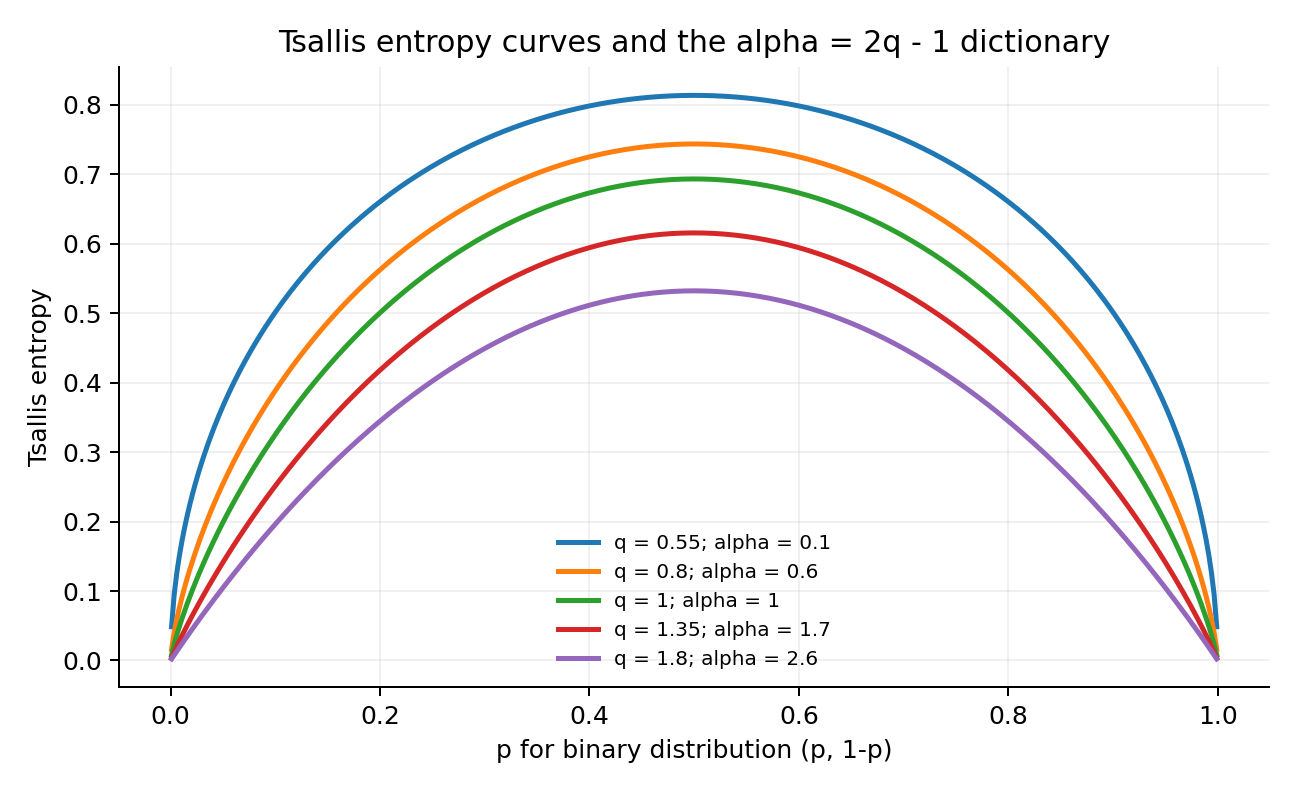

In [6]:
def tsallis_entropy(prob, q):
    prob = np.asarray(prob, dtype=float)
    if np.isclose(q, 1.0):
        return float(-np.sum(prob * np.log(prob)))
    return float((1.0 - np.sum(prob ** q)) / (q - 1.0))

grid = np.linspace(0.001, 0.999, 400)
q_values = [0.55, 0.8, 1.0, 1.35, 1.8]
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for q in q_values:
    vals = [tsallis_entropy([u, 1-u], q) for u in grid]
    ax.plot(grid, vals, lw=2, label=f'q = {q:g}; alpha = {2*q-1:g}')
ax.set_xlabel('p for binary distribution (p, 1-p)')
ax.set_ylabel('Tsallis entropy')
ax.set_title('Tsallis entropy curves and the alpha = 2q - 1 dictionary')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(artifact_path('tsallis_entropy_curves.png'), dpi=180)
plt.close(fig)
display_artifact('tsallis_entropy_curves.png', width=720)


## 5. Escort distributions reweight the same point

The `q`-escort distribution replaces `p_i` by `p_i^q` and renormalizes. For `q > 1`, large coordinates are amplified; for `q < 1`, small coordinates receive more relative mass. This is not merely a plotting trick: the escort coordinates supply a different flat structure and the metric is conformally related to the invariant geometry in the special `q` case.

The Plotly artifact lets us orbit around the escort flow from one categorical distribution as `q` varies.

In [ ]:
def escort(p, q):
    powered = np.asarray(p, dtype=float) ** q
    return powered / powered.sum()

base = np.array([0.66, 0.25, 0.09])
q_grid = np.linspace(0.25, 3.0, 130)
escorts = np.vstack([escort(base, q) for q in q_grid])
fig = go.Figure()
fig.add_trace(go.Scatterternary(
    a=escorts[:,0], b=escorts[:,1], c=escorts[:,2],
    mode='lines+markers',
    marker=dict(size=4, color=q_grid, colorscale='Viridis', colorbar=dict(title='q')),
    line=dict(width=3, color='rgba(30, 90, 160, 0.75)'),
    text=[f'q={q:.2f}<br>{row.round(3)}' for q, row in zip(q_grid, escorts)],
    hoverinfo='text',
    name='escort flow',
))
fig.add_trace(go.Scatterternary(
    a=[base[0]], b=[base[1]], c=[base[2]], mode='markers+text',
    marker=dict(size=11, color='black'), text=['base p'], textposition='top center',
    name='base distribution'
))
fig.update_layout(
    title='q-escort flow on the simplex',
    ternary=dict(sum=1, aaxis_title='category 1', baxis_title='category 2', caxis_title='category 3'),
    margin=dict(l=20, r=20, t=55, b=20),
    width=760,
    height=560,
)
fig.write_html(artifact_path('escort_distribution_flow.html'), include_plotlyjs=True, full_html=True)
display_artifact('escort_distribution_flow.html')


## 6. Applied lab: alpha integration of experts

Suppose three experts return categorical predictive distributions. Alpha integration averages them in `h_alpha` coordinates and then normalizes. Negative alpha values lean toward mixture-like pooling, positive alpha values lean toward multiplicative/exponential pooling, and intermediate values create a tunable compromise.

The lab below scores the integrated prediction against a held-out empirical distribution using alpha divergence. It is deliberately small, but it models the chapter's expert-machine idea: choose the representation first, integrate linearly there, and only then return to probabilities.

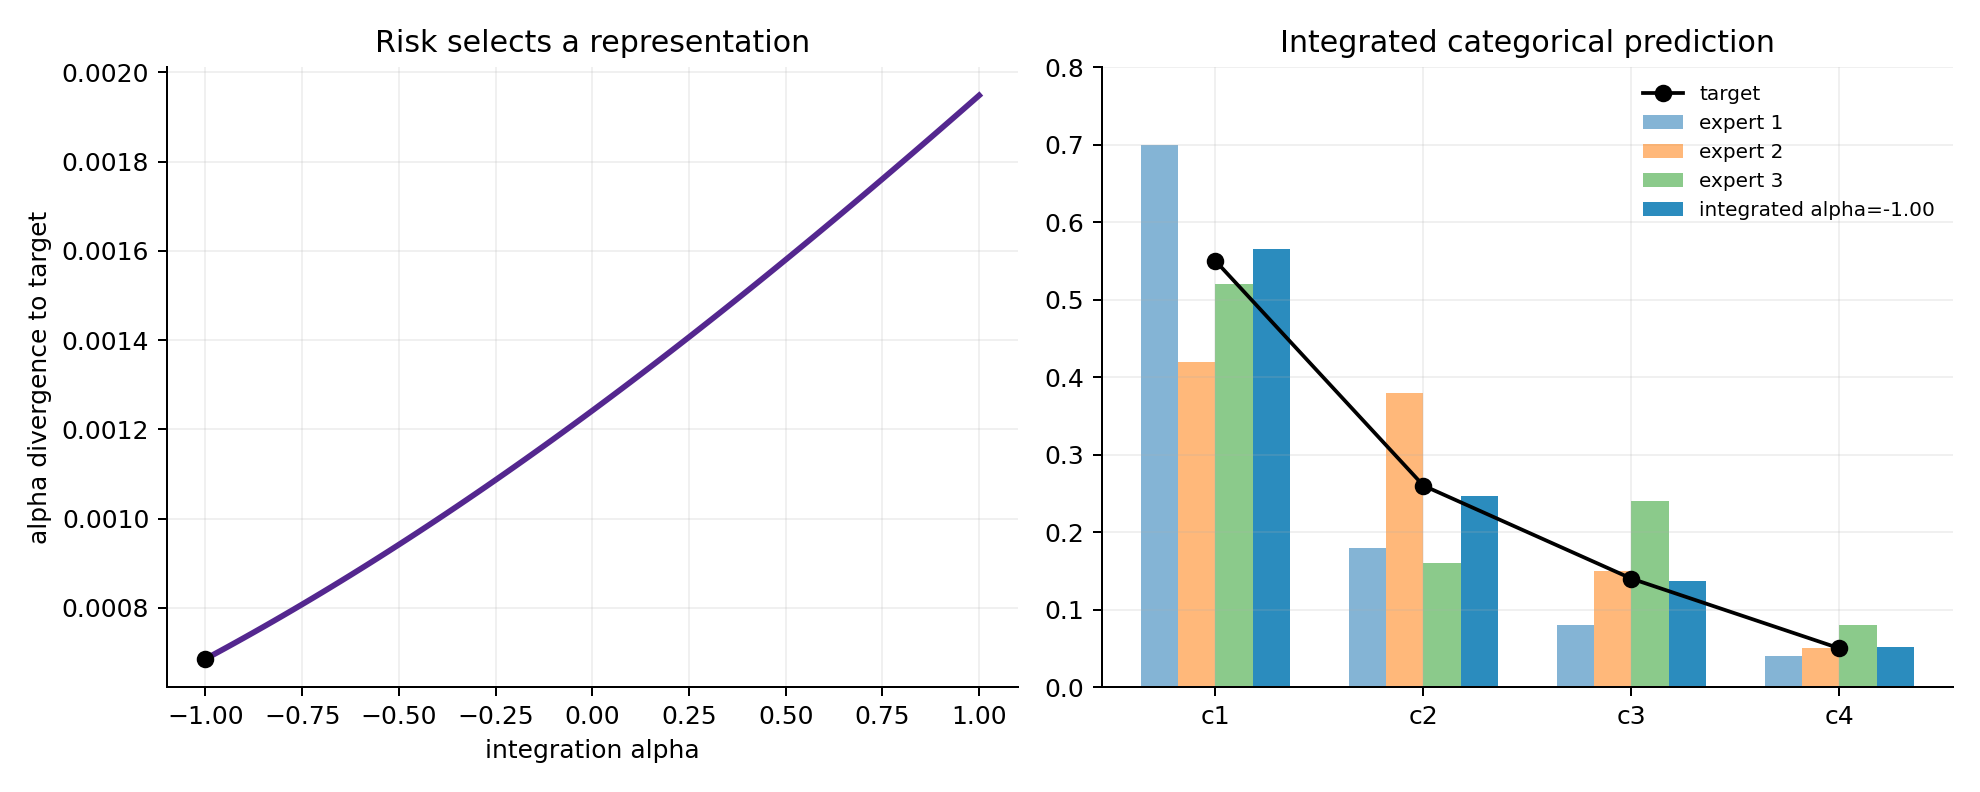

{'best_alpha': -1.0,
 'best_prediction': [0.566, 0.246, 0.1365, 0.0515],
 'best_risk': 0.0006858877401797717}

In [8]:
experts = np.array([
    [0.70, 0.18, 0.08, 0.04],
    [0.42, 0.38, 0.15, 0.05],
    [0.52, 0.16, 0.24, 0.08],
])
expert_weights = np.array([0.45, 0.35, 0.20])
target = np.array([0.55, 0.26, 0.14, 0.05])

def alpha_integrate(distributions, weights, alpha):
    reps = np.vstack([h_alpha(row, alpha) for row in distributions])
    pooled = np.sum(weights[:, None] * reps, axis=0)
    return normalize(h_inv(pooled, alpha))

lab_alphas = np.linspace(-1, 1, 81)
pooled = np.vstack([alpha_integrate(experts, expert_weights, a) for a in lab_alphas])
risks = np.array([alpha_divergence(target, row, a) for a, row in zip(lab_alphas, pooled)])
best_idx = int(np.argmin(risks))
best_alpha = float(lab_alphas[best_idx])
best_prediction = pooled[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].plot(lab_alphas, risks, color='#54278f', lw=2.3)
axes[0].scatter([best_alpha], [risks[best_idx]], color='black', zorder=5)
axes[0].set_xlabel('integration alpha')
axes[0].set_ylabel('alpha divergence to target')
axes[0].set_title('Risk selects a representation')

x = np.arange(target.size)
width = 0.18
for j, row in enumerate(experts):
    axes[1].bar(x + (j-1.5)*width, row, width=width, alpha=0.55, label=f'expert {j+1}')
axes[1].bar(x + 1.5*width, best_prediction, width=width, color='#2b8cbe', label=f'integrated alpha={best_alpha:.2f}')
axes[1].plot(x, target, 'ko-', lw=1.5, label='target')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'c{i+1}' for i in x])
axes[1].set_ylim(0, 0.8)
axes[1].set_title('Integrated categorical prediction')
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(artifact_path('alpha_expert_integration_lab.png'), dpi=180)
plt.close(fig)
display_artifact('alpha_expert_integration_lab.png', width=900)

{'best_alpha': best_alpha, 'best_prediction': best_prediction.round(4).tolist(), 'best_risk': float(risks[best_idx])}


## 7. Positive-definite matrices: from coordinates to log-det divergence

A positive-definite matrix extends the role of a positive measure from diagonal entries to spectra and orientations. One central invariant divergence is the Gaussian covariance, or Stein/log-det, form

`D(P : Q) = tr(P Q^{-1}) - log det(P Q^{-1}) - n`.

It is nonnegative, zero only at `P = Q`, and invariant under congruence transformations `P -> A P A^T`, `Q -> A Q A^T`. The next static figure shows its landscape on diagonal `2 x 2` matrices around the identity. The interactive surface then fixes `Q` and varies two coordinates of `P`, revealing the steep wall near loss of positive definiteness.

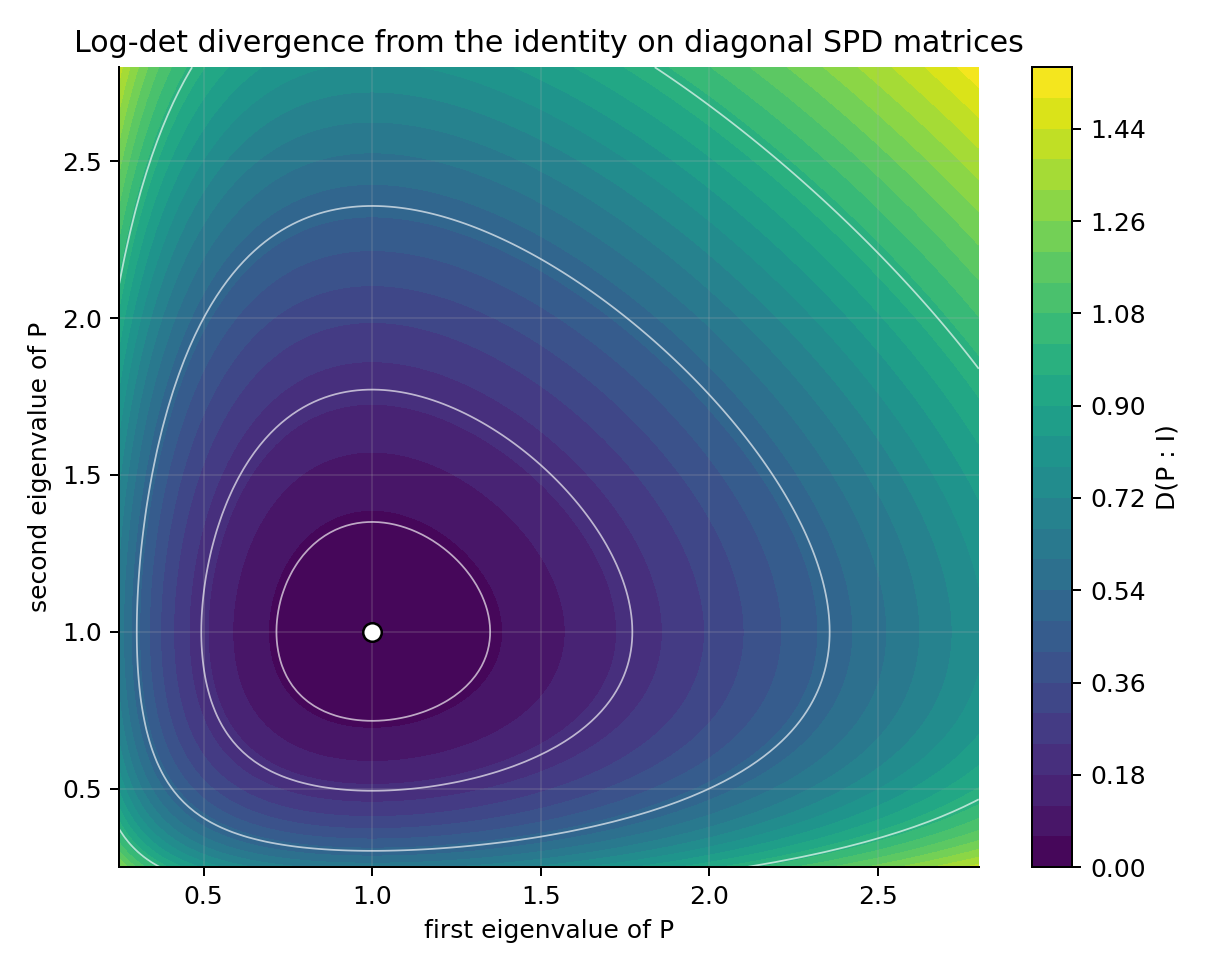

In [9]:
def spd_logdet_divergence(P, Q):
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)
    X = P @ np.linalg.inv(Q)
    sign, logdet = np.linalg.slogdet(X)
    if sign <= 0:
        return float('nan')
    return float(np.trace(X) - logdet - P.shape[0])

def spd2(a, b, c):
    return np.array([[a, c], [c, b]], dtype=float)

xs = np.linspace(0.25, 2.8, 160)
ys = np.linspace(0.25, 2.8, 160)
X, Y = np.meshgrid(xs, ys)
Z = X + Y - np.log(X * Y) - 2.0

fig, ax = plt.subplots(figsize=(6.8, 5.4))
cont = ax.contourf(X, Y, Z, levels=28, cmap='mako' if 'mako' in plt.colormaps() else 'viridis')
ax.contour(X, Y, Z, levels=[0.05, 0.2, 0.5, 1.0, 2.0], colors='white', linewidths=0.7, alpha=0.65)
ax.scatter([1], [1], color='white', edgecolor='black', s=55, zorder=5)
ax.set_xlabel('first eigenvalue of P')
ax.set_ylabel('second eigenvalue of P')
ax.set_title('Log-det divergence from the identity on diagonal SPD matrices')
fig.colorbar(cont, ax=ax, label='D(P : I)')
fig.tight_layout()
fig.savefig(artifact_path('spd_logdet_landscape.png'), dpi=180)
plt.close(fig)
display_artifact('spd_logdet_landscape.png', width=700)


In [ ]:
a_vals = np.linspace(0.35, 2.6, 70)
c_vals = np.linspace(-0.8, 0.8, 70)
Agrid, Cgrid = np.meshgrid(a_vals, c_vals)
Q = spd2(1.2, 0.35, 0.12)
Z = np.empty_like(Agrid)
for i in range(Agrid.shape[0]):
    for j in range(Agrid.shape[1]):
        P = spd2(Agrid[i, j], 1.4, Cgrid[i, j])
        Z[i, j] = spd_logdet_divergence(P, Q) if np.linalg.det(P) > 0 else np.nan

fig = go.Figure(data=[go.Surface(x=Agrid, y=Cgrid, z=Z, colorscale='Cividis', colorbar=dict(title='D'))])
fig.update_layout(
    title='Log-det divergence surface for P=[[a,c],[c,1.4]] against fixed Q',
    scene=dict(xaxis_title='a', yaxis_title='c', zaxis_title='D(P : Q)'),
    width=780,
    height=560,
    margin=dict(l=10, r=10, t=55, b=10),
)
fig.write_html(artifact_path('spd_logdet_surface.html'), include_plotlyjs=True, full_html=True)
display_artifact('spd_logdet_surface.html')


In [11]:
P = spd2(1.8, 0.9, 0.22)
Q = spd2(0.8, 1.5, -0.18)
A = np.array([[1.2, 0.4], [-0.25, 0.95]])
congruence_error = abs(
    spd_logdet_divergence(A @ P @ A.T, A @ Q @ A.T) - spd_logdet_divergence(P, Q)
)
nonneg_samples = []
rng = np.random.default_rng(42)
for _ in range(16):
    M = rng.normal(size=(2,2))
    N = rng.normal(size=(2,2))
    P_sample = M @ M.T + 0.25 * np.eye(2)
    Q_sample = N @ N.T + 0.25 * np.eye(2)
    nonneg_samples.append(spd_logdet_divergence(P_sample, Q_sample))

spd_checks = {
    'congruence_error': float(congruence_error),
    'minimum_random_logdet_divergence': float(np.min(nonneg_samples)),
    'zero_at_identity': spd_logdet_divergence(np.eye(2), np.eye(2)),
}
spd_checks


{'congruence_error': 0.0,
 'minimum_random_logdet_divergence': 0.31545820058152696,
 'zero_at_identity': 0.0}

## 8. Synthesis and pitfalls

The chapter's moving parts can be organized as three coordinate choices.

1. Positive measures: alpha representations make the cone dually flat, with KL appearing as a limiting endpoint.
2. Probabilities: the simplex constraint bends most alpha coordinates, so alpha geodesics remain meaningful but global flatness is exceptional.
3. Escorts and matrices: escorts provide a second way to flatten by changing the probability representation, while SPD matrices generalize positive measures through spectra and congruence-invariant log-det formulas.

Common pitfalls:

- Treating `q` and `alpha` as unrelated parameters. In this chapter they are tied by `alpha = 2q - 1`.
- Forgetting the normalization step when an alpha geodesic is drawn inside the simplex.
- Assuming every invariant divergence is flat. The log-det family includes flat and non-flat examples; the metric and the chosen affine coordinates matter.
- Reading escort distributions as ad hoc weights. They are coordinates in a dual flat construction, not just a heuristic smoothing rule.

## Takeaways

- Alpha geometry is flat on the positive cone because the power/log representation straightens its affine coordinates.
- The probability simplex inherits alpha geodesics, projections, and constant-curvature identities, but it is not usually flat under the same coordinates.
- Tsallis `q` entropy is the same deformation viewed through `q`; the conversion is `alpha = 2q - 1`.
- Escort distributions reweight probabilities by powers and create an important conformal flattening in the special `q` case.
- Positive-definite matrices extend positive measures: diagonal spectra behave like measures, while congruence invariance captures the matrix analogue of changing coordinates.

In [12]:
artifact_names = [
    'alpha_geodesics_simplex.png',
    'alpha_mean_path.png',
    'tsallis_entropy_curves.png',
    'escort_distribution_flow.html',
    'alpha_expert_integration_lab.png',
    'spd_logdet_landscape.png',
    'spd_logdet_surface.html',
]
artifact_sizes = {name: artifact_path(name).stat().st_size for name in artifact_names}

sanity = {
    'chapter': CHAPTER,
    'source_orientation': {'printed_pages': '71-106', 'pdf_pages': '82-117'},
    'artifact_sizes': artifact_sizes,
    'alpha_pythagorean_error': float(pythagorean_terms['identity_error']),
    'escort_sums_to_one_error': float(np.max(np.abs(escorts.sum(axis=1) - 1.0))),
    'expert_lab': {
        'best_alpha': best_alpha,
        'best_prediction_sum_error': float(abs(best_prediction.sum() - 1.0)),
        'best_risk': float(risks[best_idx]),
    },
    'spd_checks': spd_checks,
    'all_checks_passed': bool(
        all(size > 1000 for size in artifact_sizes.values())
        and pythagorean_terms['identity_error'] < 1e-10
        and np.max(np.abs(escorts.sum(axis=1) - 1.0)) < 1e-12
        and abs(best_prediction.sum() - 1.0) < 1e-12
        and spd_checks['congruence_error'] < 1e-10
        and spd_checks['minimum_random_logdet_divergence'] > -1e-12
        and abs(spd_checks['zero_at_identity']) < 1e-12
    ),
}
artifact_path('final_sanity.json').write_text(json.dumps(sanity, indent=2), encoding='utf-8')
sanity


{'chapter': 'chapter-04',
 'source_orientation': {'printed_pages': '71-106', 'pdf_pages': '82-117'},
 'artifact_sizes': {'alpha_geodesics_simplex.png': 97802,
  'alpha_mean_path.png': 59491,
  'tsallis_entropy_curves.png': 149894,
  'escort_distribution_flow.html': 21093,
  'alpha_expert_integration_lab.png': 101580,
  'spd_logdet_landscape.png': 141685,
  'spd_logdet_surface.html': 202951},
 'alpha_pythagorean_error': 0.0,
 'escort_sums_to_one_error': 2.220446049250313e-16,
 'expert_lab': {'best_alpha': -1.0,
  'best_prediction_sum_error': 2.220446049250313e-16,
  'best_risk': 0.0006858877401797717},
 'spd_checks': {'congruence_error': 0.0,
  'minimum_random_logdet_divergence': 0.31545820058152696,
  'zero_at_identity': 0.0},
 'all_checks_passed': True}

## Standalone Synthesis

The chapter focus is: Alpha geometry, alpha geodesics and projections, Tsallis q-entropy, escort geometry, positive measures, positive-definite matrices, and miscellaneous divergences.

Key computational translations:

- alpha changes which coordinates look affine. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- q-logarithms and q-exponentials deform ordinary exponential-family calculations. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- escort distributions reweight outcomes before measuring geometry. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- matrix divergences expose invariance under structured transformations. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.

How to read the visual sequence:

- alpha-geodesic family sweeping across the simplex. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- q-logarithm and q-exponential deformation dashboard. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- escort-distribution flow as q varies. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- positive-definite matrix cone with divergence contours. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.


## Course Standard Note

**Source span:** printed pages 71-106; PDF pages 88-123. The PDF is used only for source orientation, not as a required companion while reading this standalone notebook. The final_sanity evidence for this chapter is stored under `artifacts/chapter-04` using the chapter's local sanity JSON naming convention.


In [ ]:
from pathlib import Path

def _discover_book_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'AGENTS.md').exists() and (candidate / 'artifacts').exists():
            return candidate
    raise RuntimeError('Could not locate book root')

BOOK_ROOT = _discover_book_root(Path.cwd())
BOOK_ROOT
